My first submission towards a Kaggle competition, I used the starter code from NCAA2026|Public|Baseline|V1 from Ravi Ramakrishnan as a starting point and heavily modified it to add in extra features and tryout the effectiveness of TabICLv2 alongside XGBoost and LightGBM

## SETUP ##

In [1]:
!pip install tabicl -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import warnings
import statsmodels.api as sm
import tqdm


from sklearn.metrics import *
from scipy.optimize import minimize        
import xgboost as xgb
from lightgbm import LGBMRegressor        
from scipy.interpolate import UnivariateSpline
from tabicl import TabICLClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_column', 999)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.5/206.5 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 62.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.


In [2]:
data_dir       = "/kaggle/input/competitions/march-machine-learning-mania-2026"
sub_file_path  = f"{data_dir}/SampleSubmissionStage2.csv"
sub1_file_path = f"{data_dir}/SampleSubmissionStage1.csv"
calibration_t  = 25
prob_cutoff    = (0.02, 0.98)

# DATA LOAD #

In [3]:
# W -> women's basketball, M -> men's basketball
M_regular_results = pd.read_csv(f"{data_dir}/MRegularSeasonDetailedResults.csv")
M_tourney_results = pd.read_csv(f"{data_dir}/MNCAATourneyDetailedResults.csv")
M_seeds = pd.read_csv(f"{data_dir}/MNCAATourneySeeds.csv")

W_regular_results = pd.read_csv(f"{data_dir}/WRegularSeasonDetailedResults.csv")
W_tourney_results = pd.read_csv(f"{data_dir}/WNCAATourneyDetailedResults.csv")
W_seeds = pd.read_csv(f"{data_dir}/WNCAATourneySeeds.csv")

regular_results = pd.concat([M_regular_results, W_regular_results])
tourney_results = pd.concat([M_tourney_results, W_tourney_results])
seeds = pd.concat([M_seeds, W_seeds])

season = 2003 
regular_results = regular_results.loc[regular_results["Season"] >= season]
tourney_results = tourney_results.loc[tourney_results["Season"] >= season]
seeds = seeds.loc[seeds["Season"] >= season]

print(f"---> Data load complete")

---> Data load complete


# EDA #
one random teams journey 

In [4]:
season = 2025
teamid = 3163

r = regular_results.loc[
    (regular_results["Season"] == season)
    & ((regular_results["WTeamID"] == teamid) | (regular_results["LTeamID"] == teamid))
]
t = tourney_results.loc[
    (tourney_results["Season"] == season)
    & ((tourney_results["WTeamID"] == teamid) | (tourney_results["LTeamID"] == teamid))
]
r["win"] = np.where(r["WTeamID"] == teamid, "win", "lose")
t["win"] = np.where(t["WTeamID"] == teamid, "win", "lose")
r["type"] = "regular season"
t["type"] = "tournament"

rt = pd.concat([r, t])
rt[["DayNum", "WScore", "LScore", "type", "win"]]

,DayNum,WScore,LScore,type,win
76407,3,86,32,regular season,win
76534,6,86,49,regular season,win
76747,11,69,58,regular season,win
76942,16,85,41,regular season,win
77170,21,71,52,regular season,win
77238,23,73,60,regular season,win
77508,29,88,52,regular season,win
77651,33,85,52,regular season,win
77814,38,79,68,regular season,lose
77874,41,79,44,regular season,win


In [5]:
# structure of seeds by division
s = W_seeds.loc[W_seeds["Season"] == 2015]
[s.loc[s["Seed"].str.startswith(d)] for d in ("X", "Y", "Z", "W")]

[      Season Seed  TeamID
 1104    2015  X01    3268
 1105    2015  X02    3397
 1106    2015  X03    3333
 1107    2015  X04    3181
 1108    2015  X05    3280
 1109    2015  X06    3203
 1110    2015  X07    3151
 1111    2015  X08    3343
 1112    2015  X09    3453
 1113    2015  X10    3338
 1114    2015  X11    3211
 1115    2015  X12    3408
 1116    2015  X13    3107
 1117    2015  X14    3355
 1118    2015  X15    3129
 1119    2015  X16    3308,
       Season Seed  TeamID
 1120    2015  Y01    3376
 1121    2015  Y02    3199
 1122    2015  Y03    3113
 1123    2015  Y04    3314
 1124    2015  Y05    3326
 1125    2015  Y06    3401
 1126    2015  Y07    3195
 1127    2015  Y08    3393
 1128    2015  Y09    3304
 1129    2015  Y10    3329
 1130    2015  Y11    3114
 1131    2015  Y12    3241
 1132    2015  Y13    3251
 1133    2015  Y14    3325
 1134    2015  Y15    3106
 1135    2015  Y16    3366,
       Season Seed  TeamID
 1136    2015  Z01    3323
 1137    2015  Z02    3124

In [6]:
# let's see what seed our previous example team had
seeds.loc[(seeds["Season"] == season) & (seeds["TeamID"] == teamid)]

,Season,Seed,TeamID
1729,2025,Z02,3163


# DATA PREPERATION #

In [7]:

def prepare_data(df):
    df = df[
    ["Season", "DayNum", "LTeamID", "LScore", "WTeamID", "WScore", "NumOT",
     "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
     "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"
    ]
    ]
    

    # adjustment factor for overtimes, as more stats are accumulated during overtimes
    adjot = (40 + 5 * df["NumOT"]) / 40
    adjcols = ["LScore", "WScore", 
               "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF",
               "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF"]
    for col in adjcols:
        df[col] = df[col] / adjot    
    
    dfswap = df.copy()
    df.columns = [x.replace("W", "T1_").replace("L", "T2_") for x in list(df.columns)]
    dfswap.columns = [x.replace("L", "T1_").replace("W", "T2_") for x in list(dfswap.columns)]
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output["PointDiff"] = output["T1_Score"] - output["T2_Score"]
    output["win"] = (output["PointDiff"] > 0) * 1
    output["men_women"] = (output["T1_TeamID"].apply(lambda t: str(t).startswith("1"))) * 1  # 0: women, 1: men
    return output

regular_data = prepare_data(regular_results)
tourney_data = prepare_data(tourney_results)

regular_data

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
0,2003,10,1328,62.0,1104,68.0,0,22.0,53.0,2.0,10.0,16.0,22.0,10.0,22.0,8.0,18.0,9.0,2.0,20.0,27.0,58.0,3.0,14.0,11.0,18.0,14.0,24.0,13.0,23.0,7.0,1.0,22.0,6.0,1,1
1,2003,10,1393,63.0,1272,70.0,0,24.0,67.0,6.0,24.0,9.0,20.0,20.0,25.0,7.0,12.0,8.0,6.0,16.0,26.0,62.0,8.0,20.0,10.0,19.0,15.0,28.0,16.0,13.0,4.0,4.0,18.0,7.0,1,1
2,2003,11,1437,61.0,1266,73.0,0,22.0,73.0,3.0,26.0,14.0,23.0,31.0,22.0,9.0,12.0,2.0,5.0,23.0,24.0,58.0,8.0,18.0,17.0,29.0,17.0,26.0,15.0,10.0,5.0,2.0,25.0,12.0,1,1
3,2003,11,1457,50.0,1296,56.0,0,18.0,49.0,6.0,22.0,8.0,15.0,17.0,20.0,9.0,19.0,4.0,3.0,23.0,18.0,38.0,3.0,9.0,17.0,31.0,6.0,19.0,11.0,12.0,14.0,2.0,18.0,6.0,1,1
4,2003,11,1208,71.0,1400,77.0,0,24.0,62.0,6.0,16.0,17.0,27.0,21.0,15.0,12.0,10.0,7.0,1.0,14.0,30.0,61.0,6.0,14.0,11.0,13.0,17.0,22.0,12.0,14.0,4.0,4.0,20.0,6.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
423427,2026,131,3471,60.0,3218,48.0,0,25.0,69.0,3.0,16.0,7.0,8.0,8.0,27.0,13.0,7.0,11.0,1.0,9.0,18.0,48.0,4.0,16.0,8.0,8.0,2.0,31.0,9.0,17.0,3.0,6.0,15.0,-12.0,0,0
423428,2026,132,3158,68.0,3220,56.0,0,23.0,61.0,9.0,27.0,13.0,21.0,16.0,26.0,12.0,9.0,5.0,1.0,12.0,23.0,58.0,7.0,21.0,3.0,5.0,9.0,25.0,10.0,13.0,2.0,4.0,17.0,-12.0,0,0
423429,2026,132,3192,79.0,3254,57.0,0,31.0,60.0,10.0,19.0,7.0,11.0,9.0,32.0,15.0,10.0,4.0,1.0,18.0,19.0,55.0,7.0,20.0,12.0,14.0,5.0,19.0,2.0,11.0,5.0,4.0,15.0,-22.0,0,0
423430,2026,132,3221,77.0,3250,70.0,0,31.0,60.0,5.0,17.0,10.0,12.0,13.0,23.0,16.0,12.0,3.0,4.0,10.0,26.0,55.0,9.0,24.0,9.0,12.0,8.0,17.0,17.0,11.0,6.0,2.0,12.0,-7.0,0,0


checking whether the data is aligned properly

In [8]:
season = regular_data["Season"] == 2025
t1, t2 = 1182, 1433
match1 = (regular_data["T1_TeamID"] == t1) & (regular_data["T2_TeamID"] == t2)
match2 = (regular_data["T1_TeamID"] == t2) & (regular_data["T2_TeamID"] == t1)
regular_data.loc[season & (match1 | match2)]

,Season,DayNum,T2_TeamID,T2_Score,T1_TeamID,T1_Score,NumOT,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T1_FGM,T1_FGA,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,PointDiff,win,men_women
118444,2025,120,1182,62.0,1433,71.0,0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,9.0,1,1
330160,2025,120,1433,71.0,1182,62.0,0,23.0,55.0,8.0,22.0,17.0,21.0,12.0,22.0,10.0,14.0,9.0,4.0,23.0,21.0,51.0,4.0,16.0,16.0,24.0,11.0,19.0,9.0,15.0,8.0,5.0,16.0,-9.0,0,1


## Easy Features ##

In [9]:
seeds["seed"] = seeds["Seed"].apply(lambda x: int(x[1:3]))

seeds_T1 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T2 = seeds[["Season", "TeamID", "seed"]].copy()
seeds_T1.columns = ["Season", "T1_TeamID", "T1_seed"]
seeds_T2.columns = ["Season", "T2_TeamID", "T2_seed"]

tourney_data = tourney_data[["Season", "T1_TeamID", "T2_TeamID", "PointDiff", "win", "men_women"]]
tourney_data = pd.merge(tourney_data, seeds_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, seeds_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["Seed_diff"] = tourney_data["T2_seed"] - tourney_data["T1_seed"]

tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff
0,2003,1421,1411,7.111111,1,1,16,16,0
1,2003,1112,1436,29.000000,1,1,1,16,15
2,2003,1113,1272,13.000000,1,1,10,7,-3
3,2003,1141,1166,6.000000,1,1,11,6,-5
4,2003,1143,1301,1.777778,1,1,8,9,1
...,...,...,...,...,...,...,...,...,...
4815,2025,3425,3163,-14.000000,0,0,1,2,1
4816,2025,3395,3400,-11.000000,0,0,2,1,-1
4817,2025,3417,3163,-34.000000,0,0,1,2,1
4818,2025,3400,3376,-17.000000,0,0,1,1,0


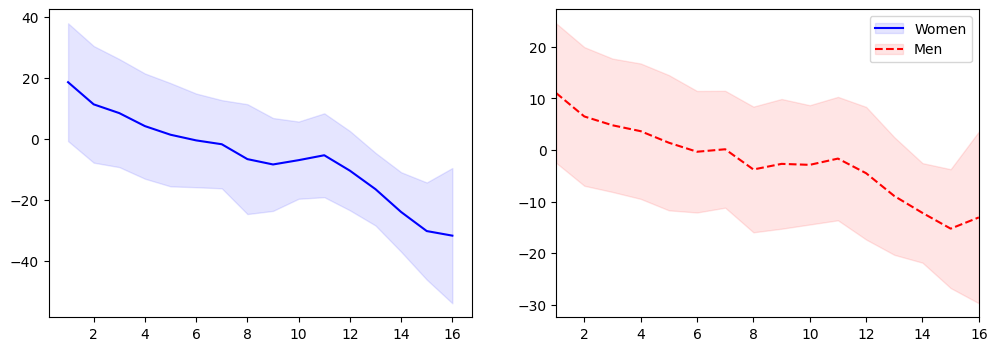

In [10]:
# let's see if __seed__ is predictive for predicting the point difference

tmpmean = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="T1_seed", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

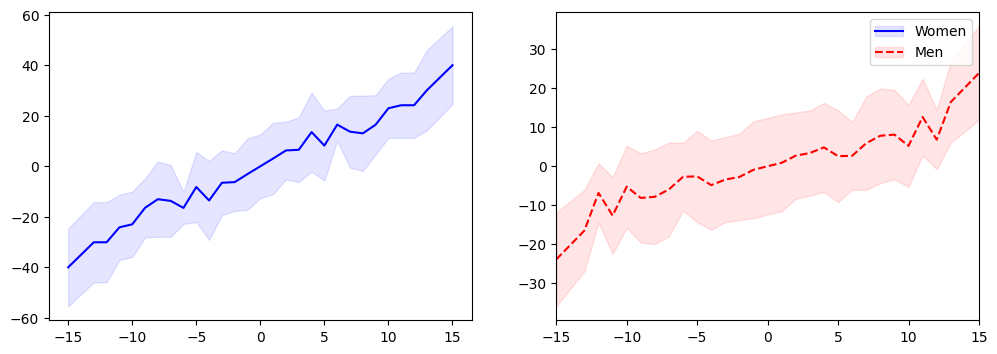

In [11]:
# let's see __seed difference__ is predictive for predicting the point difference

tmpmean = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="mean").ffill()
tmpstd = tourney_data.pivot_table(columns="men_women", index="Seed_diff", values="PointDiff", aggfunc="std").ffill()
fig, axis = plt.subplots(ncols=2, figsize=(12, 4))
(line_1,) = axis[0].plot(tmpmean.index, tmpmean[0], "b-")
fill_1 = axis[0].fill_between(tmpmean.index, tmpmean[0] - tmpstd[0], tmpmean[0] + tmpstd[0], color="b", alpha=0.1)
(line_2,) = axis[1].plot(tmpmean.index, tmpmean[1], "r--")
fill_2 = axis[1].fill_between(tmpmean.index, tmpmean[1] - tmpstd[1], tmpmean[1] + tmpstd[1], color="r", alpha=0.1)
plt.margins(x=0)
plt.legend([(line_1, fill_1), (line_2, fill_2)], ["Women", "Men"])

##  Medium Features ##

In [12]:
# box score columns, for which we want features to our model
boxcols = [
    "T1_Score", "T1_FGM", "T1_FGA", "T1_FGM3", "T1_FGA3", "T1_FTM", "T1_FTA",
    "T1_OR", "T1_DR", "T1_Ast", "T1_TO", "T1_Stl", "T1_Blk", "T1_PF",
    "T2_Score", "T2_FGM", "T2_FGA", "T2_FGM3", "T2_FGA3", "T2_FTM", "T2_FTA",
    "T2_OR", "T2_DR", "T2_Ast", "T2_TO", "T2_Stl", "T2_Blk", "T2_PF",
    "PointDiff",
]

ss = regular_data.groupby(["Season", "T1_TeamID"])[boxcols].agg("mean").reset_index()

ss_T1 = ss.copy()
ss_T1.columns = ["T1_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T1.columns)]
ss_T1 = ss_T1.rename({"T1_avg_Season": "Season", "T1_avg_TeamID": "T1_TeamID"}, axis=1)
ss_T2 = ss.copy()
ss_T2.columns = ["T2_avg_" + x.replace("T1_", "").replace("T2_", "opponent_") for x in list(ss_T2.columns)]
ss_T2 = ss_T2.rename({"T2_avg_Season": "Season", "T2_avg_TeamID": "T2_TeamID"}, axis=1)

tourney_data = pd.merge(tourney_data, ss_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, ss_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data

,Season,T1_TeamID,T2_TeamID,PointDiff,win,men_women,T1_seed,T2_seed,Seed_diff,T1_avg_Score,T1_avg_FGM,T1_avg_FGA,T1_avg_FGM3,T1_avg_FGA3,T1_avg_FTM,T1_avg_FTA,T1_avg_OR,T1_avg_DR,T1_avg_Ast,T1_avg_TO,T1_avg_Stl,T1_avg_Blk,T1_avg_PF,T1_avg_opponent_Score,T1_avg_opponent_FGM,T1_avg_opponent_FGA,T1_avg_opponent_FGM3,T1_avg_opponent_FGA3,T1_avg_opponent_FTM,T1_avg_opponent_FTA,T1_avg_opponent_OR,T1_avg_opponent_DR,T1_avg_opponent_Ast,T1_avg_opponent_TO,T1_avg_opponent_Stl,T1_avg_opponent_Blk,T1_avg_opponent_PF,T1_avg_PointDiff,T2_avg_Score,T2_avg_FGM,T2_avg_FGA,T2_avg_FGM3,T2_avg_FGA3,T2_avg_FTM,T2_avg_FTA,T2_avg_OR,T2_avg_DR,T2_avg_Ast,T2_avg_TO,T2_avg_Stl,T2_avg_Blk,T2_avg_PF,T2_avg_opponent_Score,T2_avg_opponent_FGM,T2_avg_opponent_FGA,T2_avg_opponent_FGM3,T2_avg_opponent_FGA3,T2_avg_opponent_FTM,T2_avg_opponent_FTA,T2_avg_opponent_OR,T2_avg_opponent_DR,T2_avg_opponent_Ast,T2_avg_opponent_TO,T2_avg_opponent_Stl,T2_avg_opponent_Blk,T2_avg_opponent_PF,T2_avg_PointDiff
0,2003,1421,1411,7.111111,1,1,16,16,0,69.615326,23.847510,55.639847,6.348659,17.658238,15.571648,20.428352,12.011494,22.652874,12.740230,15.931034,6.927969,2.937165,18.769349,76.947893,27.242146,59.712644,7.459004,20.307280,15.004598,22.157854,13.463602,22.401533,15.563218,12.568582,8.679693,4.141762,18.265134,-7.332567,72.533333,24.644444,55.051852,5.911111,18.437037,17.333333,27.929630,13.103704,24.677778,14.140741,15.166667,6.407407,2.222222,18.211111,70.585185,25.581481,60.140741,7.507407,23.051852,11.914815,18.655556,11.881481,22.781481,13.718519,14.259259,7.977778,2.596296,21.533333,1.948148
1,2003,1112,1436,29.000000,1,1,1,16,15,84.511905,30.067460,65.087302,6.984127,19.857143,17.392857,24.813492,15.051587,27.440476,17.488095,14.666667,8.396825,4.186508,17.587302,69.531746,26.115079,64.107143,6.253968,19.797619,11.047619,17.503968,12.980159,23.067460,15.341270,16.738095,5.904762,2.369048,21.888889,14.980159,67.255172,24.634483,55.427586,5.241379,15.310345,12.744828,19.379310,12.903448,25.565517,14.096552,13.993103,6.841379,2.958621,15.703448,62.565517,22.600000,54.696552,7.034483,21.344828,10.331034,15.482759,9.517241,21.641379,13.158621,12.910345,7.082759,3.655172,17.772414,4.689655
2,2003,1113,1272,13.000000,1,1,10,7,-3,75.344828,27.003831,56.436782,3.977011,12.475096,17.360153,25.877395,13.501916,23.111111,15.448276,13.881226,5.164751,4.191571,19.260536,68.574713,24.574713,55.176245,5.398467,15.766284,14.026820,20.375479,10.931034,20.367816,13.946360,15.402299,5.950192,3.908046,22.624521,6.770115,74.210728,26.183908,59.762452,6.969349,19.996169,14.873563,22.766284,14.019157,25.846743,16.555556,13.739464,7.363985,5.042146,18.693487,65.517241,23.164751,57.593870,5.854406,18.218391,13.333333,20.659004,12.295019,23.482759,13.237548,15.019157,7.252874,3.153257,19.827586,8.693487
3,2003,1141,1166,6.000000,1,1,11,6,-5,79.344828,26.620690,52.689655,6.827586,17.931034,19.275862,25.172414,10.586207,23.275862,15.620690,18.241379,7.103448,4.000000,20.965517,73.241379,26.344828,57.931034,4.965517,13.896552,15.586207,21.965517,12.241379,18.896552,11.793103,16.068966,8.448276,2.482759,21.689655,6.103448,79.006734,28.619529,57.289562,7.942761,20.424242,13.824916,19.952862,10.848485,23.097643,16.784512,13.309764,8.370370,4.427609,17.205387,64.107744,23.797980,55.148148,4.868687,14.282828,11.643098,16.619529,11.020202,21.289562,12.329966,17.006734,6.306397,2.569024,19.323232,14.898990
4,2003,1143,1301,1.777778,1,1,8,9,1,73.636015,27.015326,57.946360,6.314176,16.789272,13.291188,19.371648,11.114943,24.095785,15.816092,14.019157,6.455939,2.758621,16.888889,68.923372,25.072797,58.114943,7.034483,21.237548,11.743295,17.214559,11.049808,22.659004,15.881226,14.708812,5.865900,2.482759,18.919540,4.712644,72.122222,24.248148,53.129630,7.940741,22.429630,15.685185,20.385185,9.700000,21.907407,14.614815,14.129630,7.737037,3.048148,18.603704,67.751852,23.337037,52.925926,5.703704,16.903704,15.374074,21.129630,10.514815,21.348148,12.511111,14.581481,7.418519,2.811111,19.262963,4.370370

In [13]:
def compute_ratings(df, norm_stats=None, save_stats=False):
    df = df.copy()
    df['T1_poss'] = (df['T1_avg_FGA'] - df['T1_avg_OR']
                     + df['T1_avg_TO'] + 0.44 * df['T1_avg_FTA'])
    df['T2_poss'] = (df['T2_avg_FGA'] - df['T2_avg_OR']
                     + df['T2_avg_TO'] + 0.44 * df['T2_avg_FTA'])

    df['T1_ortg'] = (df['T1_avg_Score']           / df['T1_poss']) * 100
    df['T2_ortg'] = (df['T2_avg_Score']           / df['T2_poss']) * 100
    df['T1_drtg'] = (df['T1_avg_opponent_Score']  / df['T1_poss']) * 100
    df['T2_drtg'] = (df['T2_avg_opponent_Score']  / df['T2_poss']) * 100
    df['T1_net_rtg'] = df['T1_ortg'] - df['T1_drtg']
    df['T2_net_rtg'] = df['T2_ortg'] - df['T2_drtg']

    rating_cols = ['T1_ortg','T1_drtg','T1_net_rtg','T2_ortg','T2_drtg','T2_net_rtg']
    stats = {}

    for col in rating_cols:
        for gender in [0, 1]:
            key = (col, gender)
            mask = df['men_women'] == gender
            if norm_stats is not None:
                # Use saved training stats — correct approach at test time
                mu, sigma = norm_stats[key]
            else:
                mu    = df.loc[mask, col].mean()
                sigma = df.loc[mask, col].std()
            if save_stats:
                stats[key] = (mu, sigma)
            if sigma > 0:
                df.loc[mask, col] = (df.loc[mask, col] - mu) / sigma

    df['ortg_diff']    = df['T1_ortg']    - df['T2_ortg']
    df['drtg_diff']    = df['T1_drtg']    - df['T2_drtg']
    df['net_rtg_diff'] = df['T1_net_rtg'] - df['T2_net_rtg']

    if save_stats:
        return df, stats
    return df

# Save normalisation stats from training data
tourney_data, RATING_NORM_STATS = compute_ratings(tourney_data, save_stats=True)

print(f"T1 mean net rating: {tourney_data['T1_net_rtg'].mean():.4f}  (expect ~0.0)")
print(f"Top 10 teams by net rating:")
print(tourney_data[['Season','T1_TeamID','men_women','T1_net_rtg']]
      .drop_duplicates().sort_values('T1_net_rtg', ascending=False)
      .head(10).to_string(index=False))

T1 mean net rating: 0.0000  (expect ~0.0)
Top 10 teams by net rating:
 Season  T1_TeamID  men_women  T1_net_rtg
   2015       3163          0    3.925346
   2016       3163          0    3.570553
   2014       3163          0    3.116695
   2018       3163          0    3.065350
   2019       1211          1    2.991968
   2017       1211          1    2.948100
   2015       1246          1    2.926408
   2010       3163          0    2.836904
   2013       3163          0    2.678189
   2017       3163          0    2.652522


In [14]:
# Check a sample of teams to confirm ratings vary meaningfully
sample = (tourney_data[['Season', 'T1_TeamID', 'T1_ortg', 'T1_drtg', 'T1_net_rtg']]
          .drop_duplicates()
          .sort_values('T1_net_rtg', ascending=False)
          .head(10))
print("Top 10 teams by net rating:")
print(sample.to_string(index=False))

print("\nBottom 10 teams by net rating:")
print((tourney_data[['Season', 'T1_TeamID', 'T1_ortg', 'T1_drtg', 'T1_net_rtg']]
       .drop_duplicates()
       .sort_values('T1_net_rtg')
       .head(10)
       .to_string(index=False)))

Top 10 teams by net rating:
 Season  T1_TeamID  T1_ortg   T1_drtg  T1_net_rtg
   2015       3163 3.210428 -2.770309    3.925346
   2016       3163 2.763250 -2.713163    3.570553
   2014       3163 2.126378 -2.719859    3.116695
   2018       3163 2.574034 -2.080935    3.065350
   2019       1211 2.848012 -1.204416    2.991968
   2017       1211 1.821083 -2.268506    2.948100
   2015       1246 1.333275 -2.772731    2.926408
   2010       3163 1.633502 -2.847394    2.836904
   2013       3163 1.870603 -2.283769    2.678189
   2017       3163 2.646687 -1.284572    2.652522

Bottom 10 teams by net rating:
 Season  T1_TeamID   T1_ortg  T1_drtg  T1_net_rtg
   2008       1164 -3.737208 1.161934   -3.637027
   2003       1421 -1.805945 3.206981   -3.584847
   2025       1384 -2.078518 2.392544   -3.229025
   2008       1290 -3.242040 0.858981   -3.052214
   2023       1411 -3.339374 0.693805   -3.011945
   2016       1221 -2.194312 1.940582   -3.004666
   2024       1212 -2.519980 1.335414   

## HARD FEATURES ##

In [15]:
def update_elo(winner_elo, loser_elo):
    expected_win = expected_result(winner_elo, loser_elo)
    change_in_elo = k_factor * (1 - expected_win)
    winner_elo += change_in_elo
    loser_elo -= change_in_elo
    return winner_elo, loser_elo


def expected_result(elo_a, elo_b):
    return 1.0 / (1 + 10 ** ((elo_b - elo_a) / elo_width))

base_elo  = 1000
elo_width = 400
k_factor  = 100

elos = []
for season in sorted(set(seeds["Season"])):
    ss = regular_data.loc[regular_data["Season"] == season]
    ss = ss.loc[ss["win"] == 1].reset_index(drop=True)
    teams = set(ss["T1_TeamID"]) | set(ss["T2_TeamID"])
    elo = dict(zip(teams, [base_elo] * len(teams)))
    for i in range(ss.shape[0]):
        w_team, l_team = ss.loc[i, "T1_TeamID"], ss.loc[i, "T2_TeamID"]
        w_elo, l_elo = elo[w_team], elo[l_team]
        w_elo_new, l_elo_new = update_elo(w_elo, l_elo)
        elo[w_team] = w_elo_new
        elo[l_team] = l_elo_new
    elo = pd.DataFrame.from_dict(elo, orient="index").reset_index()
    elo = elo.rename({"index": "TeamID", 0: "elo"}, axis=1)
    elo["Season"] = season
    elos.append(elo)
    
elos = pd.concat(elos)

elos_T1 = elos.copy().rename({"TeamID": "T1_TeamID", "elo": "T1_elo"}, axis=1)
elos_T2 = elos.copy().rename({"TeamID": "T2_TeamID", "elo": "T2_elo"}, axis=1)
tourney_data = pd.merge(tourney_data, elos_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, elos_T2, on=["Season", "T2_TeamID"], how="left")
tourney_data["elo_diff"] = tourney_data["T1_elo"].values - tourney_data["T2_elo"].values

# MOV-ELO #
Margin of victory ELO, blowout wins earn larger rating changes, this will capture form of teams entering tournament

In [16]:
base_elo_mov  = 1500
elo_width_mov = 400
k_factor_mov  = 32
CARRYOVER     = 0.25

def mov_elo_update(w_elo, l_elo, margin):
    expected = 1.0 / (1 + 10 ** ((l_elo - w_elo) / elo_width_mov))
    mov_mult = np.log(abs(margin) + 1) / (2.2 * ((w_elo - l_elo) * 0.001 + 2.2))
    k = k_factor_mov * mov_mult
    w_elo_new = w_elo + k * (1 - expected)
    l_elo_new = l_elo - k * (1 - expected)
    return w_elo_new, l_elo_new

prev_elos = {}

mov_elos = []
for season in sorted(regular_results['Season'].unique()):
    ss = regular_results.loc[regular_results['Season'] == season].copy()
    ss = ss.sort_values('DayNum').reset_index(drop=True)
    teams = set(ss['WTeamID']) | set(ss['LTeamID'])

    elo = {}
    for team in teams:
        prev = prev_elos.get(team, base_elo_mov)
        elo[team] = CARRYOVER * prev + (1 - CARRYOVER) * base_elo_mov

    for _, row in ss.iterrows():
        w, l   = row['WTeamID'], row['LTeamID']
        margin = row['WScore'] - row['LScore']
        elo[w], elo[l] = mov_elo_update(elo[w], elo[l], margin)

    for team, rating in elo.items():
        prev_elos[team] = rating

    tmp = pd.DataFrame({'TeamID': list(elo.keys()), 'mov_elo': list(elo.values())})
    tmp['Season'] = season
    mov_elos.append(tmp)

mov_elos = pd.concat(mov_elos, ignore_index=True)

mov_elos_T1 = mov_elos.copy().rename(columns={'TeamID':'T1_TeamID','mov_elo':'T1_mov_elo'})
mov_elos_T2 = mov_elos.copy().rename(columns={'TeamID':'T2_TeamID','mov_elo':'T2_mov_elo'})

tourney_data = pd.merge(tourney_data, mov_elos_T1, on=['Season','T1_TeamID'], how='left')
tourney_data = pd.merge(tourney_data, mov_elos_T2, on=['Season','T2_TeamID'], how='left')
tourney_data['mov_elo_diff'] = tourney_data['T1_mov_elo'] - tourney_data['T2_mov_elo']


print(f'---> MOV-Elo complete. Seasons covered: {mov_elos.Season.nunique()}')

---> MOV-Elo complete. Seasons covered: 24


# Strength of Schedule and Momentum #
average MOV-ELO of each teams opponents - strength of schedule
momentum - win rate in last 10-regular season games


In [17]:
# ── Strength of Schedule ───
mov_elo_lookup = mov_elos.set_index(['Season','TeamID'])['mov_elo'].to_dict()

sos_rows = []
for season in sorted(regular_results['Season'].unique()):
    ss = regular_results.loc[regular_results['Season'] == season]
    for team in set(ss['WTeamID']) | set(ss['LTeamID']):
        opp_w = ss.loc[ss['WTeamID'] == team, 'LTeamID']
        opp_l = ss.loc[ss['LTeamID'] == team, 'WTeamID']
        opponents = pd.concat([opp_w, opp_l])
        opp_elos  = [mov_elo_lookup.get((season, o), base_elo_mov) for o in opponents]
        sos_rows.append({'Season': season, 'TeamID': team,
                         'sos': np.mean(opp_elos) if opp_elos else base_elo_mov})

sos_df   = pd.DataFrame(sos_rows)
sos_T1   = sos_df.rename(columns={'TeamID':'T1_TeamID','sos':'T1_sos'})
sos_T2   = sos_df.rename(columns={'TeamID':'T2_TeamID','sos':'T2_sos'})
tourney_data = pd.merge(tourney_data, sos_T1, on=['Season','T1_TeamID'], how='left')
tourney_data = pd.merge(tourney_data, sos_T2, on=['Season','T2_TeamID'], how='left')
tourney_data['sos_diff'] = tourney_data['T1_sos'] - tourney_data['T2_sos']
print(f'---> SOS complete')

# ── Momentum: last-10-game win rate ────
momentum_rows = []
LAST_N = 10
for season in sorted(regular_results['Season'].unique()):
    ss = regular_results.loc[regular_results['Season'] == season].sort_values('DayNum')
    for team in set(ss['WTeamID']) | set(ss['LTeamID']):
        games_w = ss.loc[ss['WTeamID'] == team, 'DayNum'].values
        games_l = ss.loc[ss['LTeamID'] == team, 'DayNum'].values
        results = ([(d, 1) for d in games_w] + [(d, 0) for d in games_l])
        results.sort(key=lambda x: x[0])
        last_n  = [r for _, r in results[-LAST_N:]]
        momentum_rows.append({'Season': season, 'TeamID': team,
                              'momentum': np.mean(last_n) if last_n else 0.5})

momentum_df = pd.DataFrame(momentum_rows)
mom_T1 = momentum_df.rename(columns={'TeamID':'T1_TeamID','momentum':'T1_momentum'})
mom_T2 = momentum_df.rename(columns={'TeamID':'T2_TeamID','momentum':'T2_momentum'})
tourney_data = pd.merge(tourney_data, mom_T1, on=['Season','T1_TeamID'], how='left')
tourney_data = pd.merge(tourney_data, mom_T2, on=['Season','T2_TeamID'], how='left')
tourney_data['momentum_diff'] = tourney_data['T1_momentum'] - tourney_data['T2_momentum']

print(f'---> Momentum complete')

---> SOS complete
---> Momentum complete


<Axes: xlabel='elo'>

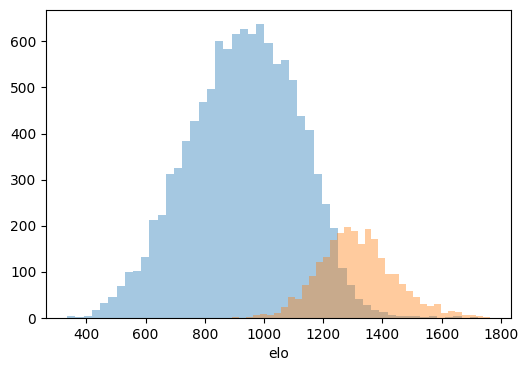

In [18]:
tmp = pd.merge(
    elos, tourney_data[['Season', 'T1_TeamID']].drop_duplicates(), 
    left_on = ['Season', 'TeamID'], 
    right_on = ['Season', 'T1_TeamID'],
    how = 'left'
)

plt.figure(figsize=(6,4))
seaborn.distplot(tmp.loc[pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)
seaborn.distplot(tmp.loc[~pd.isnull(tmp['T1_TeamID']),'elo'], kde=False)

<Axes: xlabel='T1_seed', ylabel='T1_elo'>

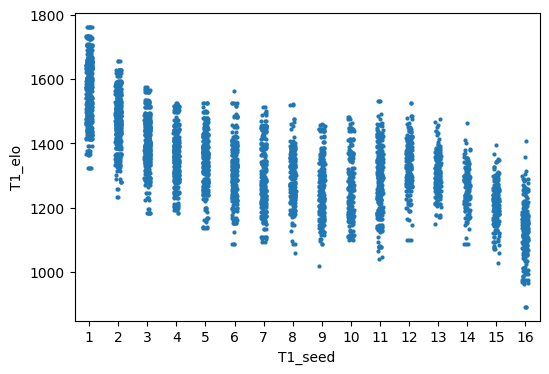

In [19]:
plt.figure(figsize=(6,4))
seaborn.stripplot(data = tourney_data, y = 'T1_elo', x = 'T1_seed', size=3)

<Axes: xlabel='Seed_diff', ylabel='elo_diff'>

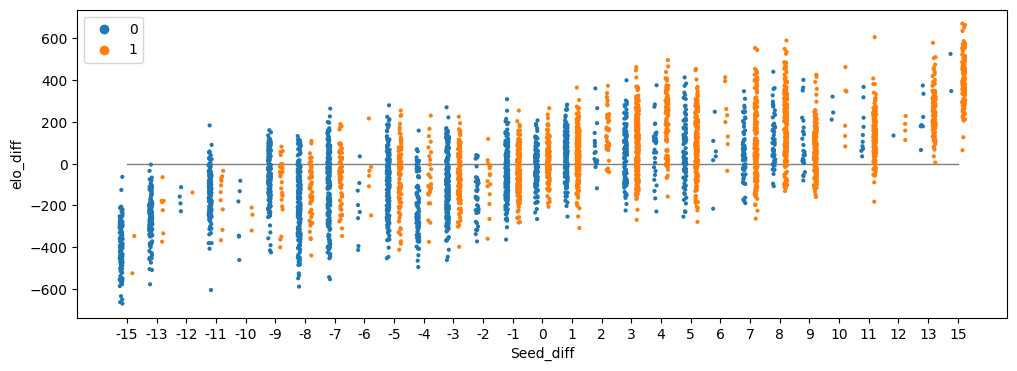

In [20]:
plt.figure(figsize=(12,4))
seaborn.stripplot(
    data = tourney_data, y = 'elo_diff', x = 'Seed_diff', hue='win', dodge=True, size=3
)
seaborn.lineplot([0]*29,color='gray',lw = 1)

# HARDEST FEATURES #

In [21]:

regular_data["ST1"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
regular_data["ST2"] = regular_data.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)
seeds_T1["ST1"] = seeds_T1.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T1_TeamID"])), axis=1)
seeds_T2["ST2"] = seeds_T2.apply(lambda t: str(int(t["Season"])) + "/" + str(int(t["T2_TeamID"])), axis=1)

# collect tourney teams
st = set(seeds_T1["ST1"]) | set(seeds_T2["ST2"])

# append non-tourney teams which were able to beat tourney team at least once
st = st | set(regular_data.loc[(regular_data["T1_Score"] > regular_data["T2_Score"]) & 
                               (regular_data["ST2"].isin(st)), "ST1"])

def team_quality(season, men_women):
    # mixed effects: fixed intercept=0, random slope
    formula = "PointDiff~-1+T1_TeamID+T2_TeamID"
    glm = sm.GLM.from_formula(
        formula=formula,
        data=dt.loc[(dt["Season"] == season) & (dt["men_women"] == men_women), :],
        family=sm.families.Gaussian(),
    ).fit()
    
    quality = pd.DataFrame(glm.params).reset_index()
    quality.columns = ["TeamID", "quality"]
    quality["quality"] = quality["quality"]
    quality["Season"] = season
    quality = quality.loc[quality.TeamID.str.contains("T1_")].reset_index(drop=True)
    quality["TeamID"] = quality["TeamID"].apply(lambda x: x[10:14]).astype(int)
    return quality


glm_quality = []

dt = regular_data.loc[regular_data["ST1"].isin(st) | regular_data["ST2"].isin(st)]
dt["T1_TeamID"] = dt["T1_TeamID"].astype(str)
dt["T2_TeamID"] = dt["T2_TeamID"].astype(str)
dt.loc[~dt["ST1"].isin(st), "T1_TeamID"] = "0000"
dt.loc[~dt["ST2"].isin(st), "T2_TeamID"] = "0000"

seasons = sorted(set(seeds["Season"]))
for s in tqdm.tqdm(seasons, unit="season"):
    if s >= 2010:  # min season for women
        glm_quality.append(team_quality(s, 0))
    if s >= 2003:  # min season for men
        glm_quality.append(team_quality(s, 1))

glm_quality = pd.concat(glm_quality).reset_index(drop=True)

glm_quality_T1 = glm_quality.copy()
glm_quality_T2 = glm_quality.copy()
glm_quality_T1.columns = ["T1_TeamID", "T1_quality", "Season"]
glm_quality_T2.columns = ["T2_TeamID", "T2_quality", "Season"]

tourney_data = pd.merge(tourney_data, glm_quality_T1, on=["Season", "T1_TeamID"], how="left")
tourney_data = pd.merge(tourney_data, glm_quality_T2, on=["Season", "T2_TeamID"], how="left")

tourney_data["diff_quality"] = tourney_data["T1_quality"].values - tourney_data["T2_quality"].values

100%|██████████| 23/23 [01:09<00:00,  3.00s/season]


QualitySeed,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
T1_seed,,,,,,,,,,,,,,,,
1,81,47,12,4,1,1,1,0,1,0,0,0,0,0,0,0
2,18,52,43,21,7,5,2,0,0,0,0,0,0,0,0,0
3,6,18,36,31,26,17,6,3,0,4,1,0,0,0,0,0
4,5,15,24,26,19,23,21,9,3,2,1,0,0,0,0,0
5,0,7,15,25,22,19,23,14,8,4,8,3,0,0,0,0
6,1,3,8,15,25,31,15,19,10,10,6,4,1,0,0,0
7,0,2,3,8,19,12,21,23,23,15,12,8,2,0,0,0
8,0,0,3,7,6,17,20,23,19,24,16,6,7,0,0,0
9,0,2,0,6,10,9,12,19,27,25,20,11,5,1,1,0


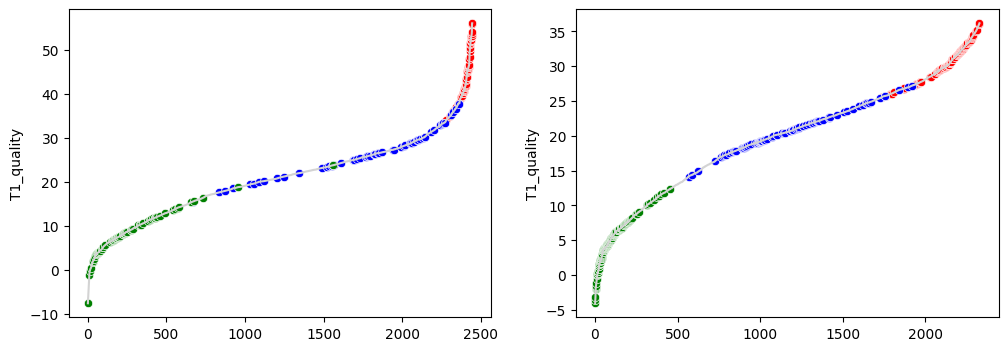

In [22]:
tmp = (
    tourney_data[["Season", "men_women", "T1_seed", "T1_quality"]]
    .drop_duplicates()
    .sort_values("T1_quality")
    .reset_index(drop=True)
)

fig, axs = plt.subplots(ncols=2, figsize=(12, 4))

seaborn.lineplot(tmp.loc[tmp["men_women"] == 0, "T1_quality"], color="lightgray", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[0])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 0) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[0])

seaborn.lineplot(tmp.loc[tmp["men_women"] == 1, "T1_quality"], color="lightgray", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 1), "T1_quality"], color="red", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 7), "T1_quality"], color="blue", ax=axs[1])
seaborn.scatterplot(tmp.loc[(tmp["men_women"] == 1) & (tmp.T1_seed == 16), "T1_quality"], color="green", ax=axs[1])

tmp["QualitySeed"] = (
    (tmp.groupby(["Season", "men_women"])["T1_quality"].rank(ascending=False) // 4 + 1).clip(1, 16).astype(int)
)

pd.pivot_table(
    data=tmp, 
    index="T1_seed", 
    columns="QualitySeed", 
    values="men_women", 
    aggfunc="count"
).fillna(0).astype(int).style.bar(color="#5fba7d", vmin=0, vmax=50)

In [23]:

print("Seed AUC    :", np.round(roc_auc_score(1 - tourney_data["win"], tourney_data["T1_seed"] - tourney_data["T2_seed"]), 3))
print("Quality AUC :", np.round(roc_auc_score(tourney_data["win"], tourney_data["T1_quality"] - tourney_data["T2_quality"]), 3))

Seed AUC    : 0.811
Quality AUC : 0.829


In [24]:
# who is better, experts or statistics, by season
for s in sorted(set(tourney_data['Season'])):
    st = tourney_data['Season'] == s
    print(s, 
          a:=np.round(roc_auc_score(1-tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_seed'] - tourney_data.loc[st, 'T2_seed']),3),
          b:=np.round(roc_auc_score(tourney_data.loc[st, "win"],tourney_data.loc[st, 'T1_quality'] - tourney_data.loc[st, 'T2_quality']),3),
          np.where(a>b, '', 'Q')
         )

2003 0.807 0.779 
2004 0.823 0.81 
2005 0.792 0.811 Q
2006 0.75 0.781 Q
2007 0.902 0.838 
2008 0.817 0.851 Q
2009 0.84 0.843 Q
2010 0.804 0.808 Q
2011 0.789 0.816 Q
2012 0.828 0.855 Q
2013 0.792 0.819 Q
2014 0.779 0.816 Q
2015 0.85 0.87 Q
2016 0.787 0.825 Q
2017 0.842 0.851 Q
2018 0.786 0.794 Q
2019 0.85 0.88 Q
2021 0.78 0.818 Q
2022 0.77 0.794 Q
2023 0.781 0.793 Q
2024 0.839 0.839 Q
2025 0.891 0.901 Q


# BASELINE MODEL #

In [25]:
features = [
    ### EASY FEATURES ###
    "men_women",    
    "T1_seed",
    "T2_seed",
    "Seed_diff",
    ### MEDIUM FEATURES ###
    "T1_avg_Score",
    #"T1_avg_FGM",
    "T1_avg_FGA",
    "T1_avg_FGM3",
    "T1_avg_FGA3",
    #"T1_avg_FTM",
    #"T1_avg_FTA",
    "T1_avg_OR",
    #"T1_avg_DR",
    #"T1_avg_Ast",
    "T1_avg_TO",
    #"T1_avg_Stl",
    #"T1_avg_Blk",
    "T1_avg_PF",
    #"T1_avg_opponent_Score",
    #"T1_avg_opponent_FGM",
    "T1_avg_opponent_FGA",
    #"T1_avg_opponent_FGM3",
    #"T1_avg_opponent_FGA3",
    #"T1_avg_opponent_FTM",
    #"T1_avg_opponent_FTA",
    #"T1_avg_opponent_OR",
    #"T1_avg_opponent_DR",
    #"T1_avg_opponent_Ast",
    #"T1_avg_opponent_TO",
    #"T1_avg_opponent_Stl",
    #"T1_avg_opponent_Blk",
    "T1_avg_opponent_PF",
    "T1_avg_PointDiff",
    "T2_avg_Score",
    #"T2_avg_FGM",
    "T2_avg_FGA",
    "T2_avg_FGM3",
    "T2_avg_FGA3",
    #"T2_avg_FTM",
    #"T2_avg_FTA",
    "T2_avg_OR",
    #"T2_avg_DR",
    #"T2_avg_Ast",
    "T2_avg_TO",
    #"T2_avg_Stl",
    #"T2_avg_Blk",
    "T2_avg_PF",
    #"T2_avg_opponent_Score",
    #"T2_avg_opponent_FGM",
    "T2_avg_opponent_FGA",
    #"T2_avg_opponent_FGM3",
    #"T2_avg_opponent_FGA3",
    #"T2_avg_opponent_FTM",
    #"T2_avg_opponent_FTA",
    #"T2_avg_opponent_OR",
    #"T2_avg_opponent_DR",
    #"T2_avg_opponent_Ast",
    #"T2_avg_opponent_TO",
    #"T2_avg_opponent_Stl",
    #"T2_avg_opponent_Blk",
    "T2_avg_opponent_PF",
    "T2_avg_PointDiff",
    ### HARD FEATURES ###
    #"T1_elo",
    #"T2_elo",    
    #"elo_diff",
    ### HARDEST FEATURES ###
    "T1_quality",
    "T2_quality",
    ### Other Features ###
    'T1_mov_elo',      
    'T2_mov_elo',
    #'mov_elo_diff',
    'T1_sos',         
    'T2_sos',
    'sos_diff',
    'T1_momentum',    
    'T2_momentum',
    #'momentum_diff',
    ### RATINGS ###
    'T1_ortg',
    'T2_ortg',
    'T1_drtg',
    'T2_drtg',
    'T1_net_rtg',
    'T2_net_rtg',
   # 'ortg_diff',
    #'drtg_diff',
    #'net_rtg_diff'
]

print(f"Number of features {len(features)}")

Number of features 39


# Recency Sample Weights #
newer seasons to have a bigger contribution to data

In [26]:
decay = 0.84
max_season = tourney_data['Season'].max()

sample_weights = np.array([
    decay ** (max_season - s) for s in tourney_data['Season']
])

# COVID bubble: games played in isolation bubble — heavily downweight
covid_mask = tourney_data['Season'].values == 2021
sample_weights[covid_mask] *= 0.10

print('Per-season average weight:')
for s in sorted(tourney_data['Season'].unique()):
    w = sample_weights[tourney_data['Season'].values == s].mean()
    bar = '█' * int(w * 20)
    note = ' ← COVID bubble' if s == 2021 else ''
    print(f'  {s}: {w:.4f} {bar}{note}')

Per-season average weight:
  2003: 0.0216 
  2004: 0.0257 
  2005: 0.0306 
  2006: 0.0364 
  2007: 0.0434 
  2008: 0.0516 █
  2009: 0.0614 █
  2010: 0.0731 █
  2011: 0.0871 █
  2012: 0.1037 ██
  2013: 0.1234 ██
  2014: 0.1469 ██
  2015: 0.1749 ███
  2016: 0.2082 ████
  2017: 0.2479 ████
  2018: 0.2951 █████
  2019: 0.3513 ███████
  2021: 0.0498  ← COVID bubble
  2022: 0.5927 ███████████
  2023: 0.7056 ██████████████
  2024: 0.8400 ████████████████
  2025: 1.0000 ████████████████████


In [27]:
# ----- XGBoost params ------
param = {}
param["objective"]         = "reg:squarederror"
param["booster"]           = "gbtree"
param["eta"]               = 0.0075
param["subsample"]         = 0.6
param["colsample_bynode"]  = 0.8
param["num_parallel_tree"] = 2
param["min_child_weight"]  = 4
param["max_depth"]         = 4
param["tree_method"]       = "hist"
param['grow_policy']       = 'lossguide'
param["max_bin"]           = 32
num_rounds = 1250

# ---- LightGBM params -----
lgbm_param = {
    'objective':         'regression',
    'learning_rate':     0.005,    
    'num_leaves':        31,
    'max_depth':         4,
    'subsample':         0.6,     
    'colsample_bytree':  0.8,
    'min_child_samples': 4,        
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'n_estimators':      2000,    
    'verbose':           -1,
}

---> Season 2003 XGB MAE: 8.65502
---> Season 2004 XGB MAE: 7.80415
---> Season 2005 XGB MAE: 8.32205
---> Season 2006 XGB MAE: 8.59891
---> Season 2007 XGB MAE: 7.58393
---> Season 2008 XGB MAE: 9.64167
---> Season 2009 XGB MAE: 8.83776
---> Season 2010 XGB MAE: 9.07545
---> Season 2011 XGB MAE: 9.59350
---> Season 2012 XGB MAE: 8.58561
---> Season 2013 XGB MAE: 10.18341
---> Season 2014 XGB MAE: 10.22140
---> Season 2015 XGB MAE: 8.08133
---> Season 2016 XGB MAE: 10.25531
---> Season 2017 XGB MAE: 10.02347
---> Season 2018 XGB MAE: 10.45249
---> Season 2019 XGB MAE: 9.79789
---> Season 2021 XGB MAE: 10.30534
---> Season 2022 XGB MAE: 10.18239
---> Season 2023 XGB MAE: 9.37980
---> Season 2024 XGB MAE: 9.64012
---> Season 2025 XGB MAE: 10.18422
XGB average MAE: 9.33660

---> Season 2003 LGBM MAE: 8.75483
---> Season 2004 LGBM MAE: 7.79607
---> Season 2005 LGBM MAE: 8.40944
---> Season 2006 LGBM MAE: 8.26572
---> Season 2007 LGBM MAE: 7.54618
---> Season 2008 LGBM MAE: 9.47764
---> Sea

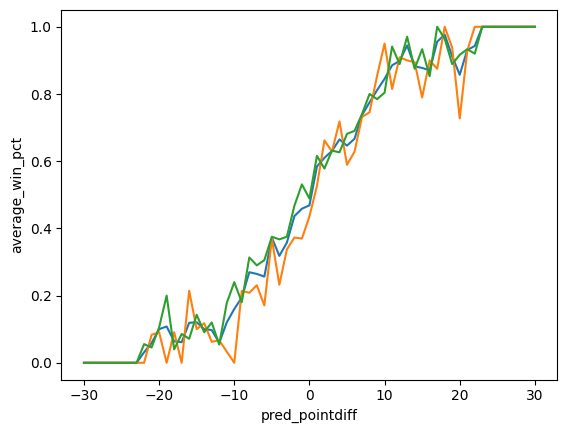

In [28]:
# - - - - XGBoost LOSO - - - - 
models     = {}
oof_mae    = []
oof_preds  = []
oof_targets = []
oof_ss     = []

for oof_season in set(tourney_data.Season):
    train_mask = tourney_data['Season'] != oof_season
    val_mask   = tourney_data['Season'] == oof_season

    x_train = tourney_data.loc[train_mask, features].values
    y_train = tourney_data.loc[train_mask, 'PointDiff'].values
    x_val   = tourney_data.loc[val_mask,   features].values
    y_val   = tourney_data.loc[val_mask,   'PointDiff'].values
    s_val   = tourney_data.loc[val_mask,   'Season'].values
    w_train = sample_weights[train_mask.values]

    dtrain = xgb.DMatrix(x_train, label=y_train, weight=w_train)
    models[oof_season] = xgb.train(
        params=param,
        dtrain=dtrain,
        num_boost_round=num_rounds,
    )
    preds = models[oof_season].predict(xgb.DMatrix(x_val))
    print(f'---> Season {oof_season} XGB MAE: {mean_absolute_error(y_val, preds):,.5f}')
    oof_mae.append(mean_absolute_error(y_val, preds))
    oof_preds   += list(preds)
    oof_targets += list(y_val)
    oof_ss      += list(s_val)

print(f'XGB average MAE: {np.mean(oof_mae):,.5f}\n')

df = pd.DataFrame({
    'Season':    oof_ss,
    'pred':      oof_preds,
    'label':     [(t > 0) * 1 for t in oof_targets],
    'men_women': tourney_data['men_women'].values,
})
df['pred_pointdiff'] = df['pred'].astype(int)

xdf_all   = df.clip(-30,30).groupby('pred_pointdiff')['label'].mean().reset_index(name='average_win_pct')
xdf_men   = df.clip(-30,30).loc[df['men_women']==0].groupby('pred_pointdiff')['label'].mean().reset_index(name='average_win_pct')
xdf_women = df.clip(-30,30).loc[df['men_women']==1].groupby('pred_pointdiff')['label'].mean().reset_index(name='average_win_pct')

seaborn.lineplot(x=xdf_all['pred_pointdiff'],   y=xdf_all['average_win_pct'])
seaborn.lineplot(x=xdf_men['pred_pointdiff'],   y=xdf_men['average_win_pct'])
seaborn.lineplot(x=xdf_women['pred_pointdiff'], y=xdf_women['average_win_pct'])

# ── LightGBM LOSO ─────────────────────────────────────────────────────────────
lgbm_models    = {}
lgbm_oof_preds = []

for oof_season in set(tourney_data.Season):
    train_mask = tourney_data['Season'] != oof_season
    val_mask   = tourney_data['Season'] == oof_season

    x_train  = tourney_data.loc[train_mask, features].values
    y_train  = tourney_data.loc[train_mask, 'PointDiff'].values
    x_val    = tourney_data.loc[val_mask,   features].values
    y_val    = tourney_data.loc[val_mask,   'PointDiff'].values  # define it here
    w_train  = sample_weights[train_mask.values]

    lgbm = LGBMRegressor(**lgbm_param)
    lgbm.fit(x_train, y_train, sample_weight=w_train)
    lgbm_models[oof_season] = lgbm

    preds = lgbm.predict(x_val)
    lgbm_oof_preds += list(preds)
    print(f'---> Season {oof_season} LGBM MAE: {mean_absolute_error(y_val, preds):,.5f}')

lgbm_oof_preds = np.array(lgbm_oof_preds)
print(f'\nLGBM LOSO complete')

In [29]:
# ── TabICLv2: single model, trained on all seasons ──────────────────────────
x_train_all = tourney_data[features].copy()
IMPUTE_MEDIANS = x_train_all.median()
x_train_all = x_train_all.fillna(IMPUTE_MEDIANS).fillna(0).values
y_train_all = tourney_data['win'].values

tabicl_model = TabICLClassifier()
tabicl_model.fit(x_train_all, y_train_all)

# Brier score on training data (slight optimistic bias — no leakage concerns
# for a foundation model since no gradient updates are performed)
tabicl_train_preds = np.clip(
    tabicl_model.predict_proba(x_train_all)[:, 1],
    prob_cutoff[0], prob_cutoff[1]
)
tabicl_brier = brier_score_loss(tourney_data['win'].values, tabicl_train_preds)
print(f'---> TabICL Brier score = {tabicl_brier:.8f}')

INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]

---> TabICL Brier score = 0.15552953


---> XGB Brier score = 0.16433097
---> LGBM Brier score = 0.16505772
---> TabICL Brier score = 0.15552953

Manual weights:
  XGBoost:  0.350
  LightGBM: 0.250
  TabICL:   0.400

Ensemble Brier (all seasons):  0.19337057
Ensemble Brier (2022-2025):    0.19077865


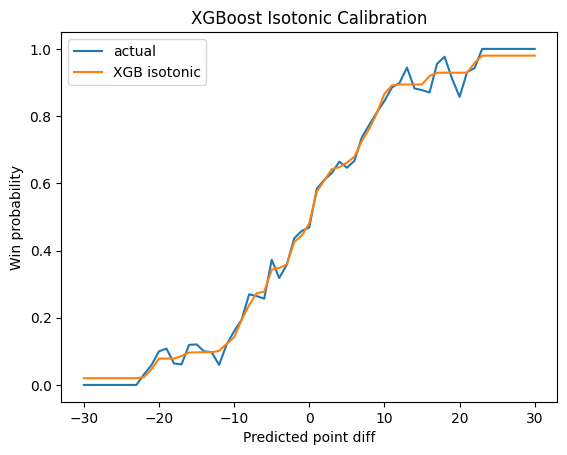

2003 0.1819323
2004 0.16102722
2005 0.16464883
2006 0.1988615
2007 0.14191091
2008 0.15040147
2009 0.16011113
2010 0.1692932
2011 0.18422921
2012 0.15629284
2013 0.17368041
2014 0.16734285
2015 0.13991845
2016 0.17299491
2017 0.15849968
2018 0.18130446
2019 0.15276978
2021 0.16863104
2022 0.18360683
2023 0.18520328
2024 0.14802658
2025 0.11973485


In [30]:
from sklearn.isotonic import IsotonicRegression

# ── XGBoost isotonic calibration ─────────────────────────────────────────────
t = calibration_t

iso_xgb = IsotonicRegression(out_of_bounds='clip')
iso_xgb.fit(np.clip(oof_preds, -t, t), np.array(oof_targets) > 0)

xgb_spline_fit = np.clip(
    iso_xgb.predict(np.clip(oof_preds, -t, t)),
    prob_cutoff[0], prob_cutoff[1]
)
print(f'---> XGB Brier score = {brier_score_loss(np.array(oof_targets)>0, xgb_spline_fit):.8f}')

# ── LightGBM isotonic calibration ────────────────────────────────────────────
iso_lgbm = IsotonicRegression(out_of_bounds='clip')
iso_lgbm.fit(np.clip(lgbm_oof_preds, -t, t), np.array(oof_targets) > 0)

lgbm_spline_fit = np.clip(
    iso_lgbm.predict(np.clip(lgbm_oof_preds, -t, t)),
    prob_cutoff[0], prob_cutoff[1]
)
print(f'---> LGBM Brier score = {brier_score_loss(np.array(oof_targets)>0, lgbm_spline_fit):.8f}')

# ── TabICL OOF ────────────────────────────────────────────────────────────────
tabicl_oof_fit = np.clip(
    tabicl_model.predict_proba(x_train_all)[:, 1],
    prob_cutoff[0], prob_cutoff[1]
)
print(f'---> TabICL Brier score = {brier_score_loss(tourney_data["win"].values, tabicl_oof_fit):.8f}')

# ── Manual ensemble weights ───────────────────────────────────────────────────
# TabICL has best individual Brier so give it most weight
W_XGB    = 0.35
W_LGBM   = 0.25
W_TABICL = 0.40

print(f'\nManual weights:')
print(f'  XGBoost:  {W_XGB:.3f}')
print(f'  LightGBM: {W_LGBM:.3f}')
print(f'  TabICL:   {W_TABICL:.3f}')

# ── Ensemble OOF Brier ────────────────────────────────────────────────────────
# Note: TabICL OOF ordering may differ from XGB/LGBM — scores here are approximate
# Submission predictions are unaffected since they use fresh predict calls
y_true      = np.array(oof_targets) > 0
recent_mask = np.array([s >= 2022 for s in oof_ss])

ensemble_oof = W_XGB * xgb_spline_fit + W_LGBM * lgbm_spline_fit + W_TABICL * tabicl_oof_fit
print(f'\nEnsemble Brier (all seasons):  {brier_score_loss(y_true, ensemble_oof):.8f}')
print(f'Ensemble Brier (2022-2025):    {brier_score_loss(y_true[recent_mask], ensemble_oof[recent_mask]):.8f}')

# ── Calibration plot (XGBoost) ────────────────────────────────────────────────
df["spline"] = xgb_spline_fit
xdf = df.clip(-30, 30).groupby('pred_pointdiff')[['spline', 'label']].mean().reset_index()

plt.figure()
plt.plot(xdf['pred_pointdiff'], xdf['label'],  label='actual')
plt.plot(xdf['pred_pointdiff'], xdf['spline'], label='XGB isotonic')
plt.legend()
plt.xlabel('Predicted point diff')
plt.ylabel('Win probability')
plt.title('XGBoost Isotonic Calibration')
plt.show()

# ── Per-season Brier (XGBoost) ────────────────────────────────────────────────
for oof_season in sorted(set(tourney_data.Season)):
    x = df.loc[df['Season'] == oof_season, 'spline'].values
    y = df.loc[df['Season'] == oof_season, 'label'].values
    print(oof_season, np.round(brier_score_loss(y, x), 8))

## SUBMISSION ##

In [31]:
X = pd.read_csv(sub_file_path)
display(X.head(5))

X['Season']    = X['ID'].apply(lambda t: int(t.split('_')[0]))
X['T1_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[1]))
X['T2_TeamID'] = X['ID'].apply(lambda t: int(t.split('_')[2]))
# FIX: align men_women with prepare_data() — men=1, women=0
X['men_women'] = X['T1_TeamID'].apply(lambda t: 1 if str(t)[0] == '1' else 0)

# ── Stage 2 fix: use most recent season's data per team ───────────────────────
def latest(df, team_col, val_col, new_name):
    return (df.sort_values('Season')
              .groupby(team_col)[val_col].last()
              .reset_index()
              .rename(columns={val_col: new_name}))

# Box score averages
ss_latest = (regular_data.sort_values('Season')
               .groupby('T1_TeamID')[boxcols].last().reset_index())
ss_latest_T1 = ss_latest.copy()
ss_latest_T1.columns = ['T1_avg_' + c.replace('T1_','').replace('T2_','opponent_')
                         for c in ss_latest_T1.columns]
ss_latest_T1 = ss_latest_T1.rename(columns={'T1_avg_TeamID':'T1_TeamID'})
ss_latest_T2 = ss_latest.copy()
ss_latest_T2.columns = ['T2_avg_' + c.replace('T1_','').replace('T2_','opponent_')
                         for c in ss_latest_T2.columns]
ss_latest_T2 = ss_latest_T2.rename(columns={'T2_avg_TeamID':'T2_TeamID'})

# Seeds
seeds_2026 = seeds[seeds['Season'] == 2026][['Season','TeamID','seed']].copy()
s_latest_T1 = seeds_2026.rename(columns={'TeamID':'T1_TeamID', 'seed':'T1_seed'})
s_latest_T2 = seeds_2026.rename(columns={'TeamID':'T2_TeamID', 'seed':'T2_seed'})

# GLM quality
q_latest_T1 = latest(glm_quality, 'TeamID', 'quality', 'T1_quality')
q_latest_T2 = latest(glm_quality, 'TeamID', 'quality', 'T2_quality')
q_latest_T1 = q_latest_T1.rename(columns={'TeamID':'T1_TeamID'})
q_latest_T2 = q_latest_T2.rename(columns={'TeamID':'T2_TeamID'})

# Standard ELO
e_latest_T1 = latest(elos, 'TeamID', 'elo', 'T1_elo')
e_latest_T2 = latest(elos, 'TeamID', 'elo', 'T2_elo')
e_latest_T1 = e_latest_T1.rename(columns={'TeamID':'T1_TeamID'})
e_latest_T2 = e_latest_T2.rename(columns={'TeamID':'T2_TeamID'})

# MOV-Elo
mov_latest_T1 = latest(mov_elos, 'TeamID', 'mov_elo', 'T1_mov_elo')
mov_latest_T2 = latest(mov_elos, 'TeamID', 'mov_elo', 'T2_mov_elo')
mov_latest_T1 = mov_latest_T1.rename(columns={'TeamID':'T1_TeamID'})
mov_latest_T2 = mov_latest_T2.rename(columns={'TeamID':'T2_TeamID'})

# SOS
sos_latest_T1 = latest(sos_df, 'TeamID', 'sos', 'T1_sos')
sos_latest_T2 = latest(sos_df, 'TeamID', 'sos', 'T2_sos')
sos_latest_T1 = sos_latest_T1.rename(columns={'TeamID':'T1_TeamID'})
sos_latest_T2 = sos_latest_T2.rename(columns={'TeamID':'T2_TeamID'})

# Momentum
mom_latest_T1 = latest(momentum_df, 'TeamID', 'momentum', 'T1_momentum')
mom_latest_T2 = latest(momentum_df, 'TeamID', 'momentum', 'T2_momentum')
mom_latest_T1 = mom_latest_T1.rename(columns={'TeamID':'T1_TeamID'})
mom_latest_T2 = mom_latest_T2.rename(columns={'TeamID':'T2_TeamID'})


# ── Merge all features ────────────────────────────────────────────────────────
X = pd.merge(X, ss_latest_T1,  on='T1_TeamID', how='left')
X = pd.merge(X, ss_latest_T2,  on='T2_TeamID', how='left')
X = pd.merge(X, s_latest_T1,   on='T1_TeamID', how='left')
X = pd.merge(X, s_latest_T2,   on='T2_TeamID', how='left')
X = pd.merge(X, q_latest_T1,   on='T1_TeamID', how='left')
X = pd.merge(X, q_latest_T2,   on='T2_TeamID', how='left')
X = pd.merge(X, e_latest_T1,   on='T1_TeamID', how='left')
X = pd.merge(X, e_latest_T2,   on='T2_TeamID', how='left')
X = pd.merge(X, mov_latest_T1, on='T1_TeamID', how='left')
X = pd.merge(X, mov_latest_T2, on='T2_TeamID', how='left')
X = pd.merge(X, sos_latest_T1, on='T1_TeamID', how='left')
X = pd.merge(X, sos_latest_T2, on='T2_TeamID', how='left')
X = pd.merge(X, mom_latest_T1, on='T1_TeamID', how='left')
X = pd.merge(X, mom_latest_T2, on='T2_TeamID', how='left')

X['Seed_diff']     = X['T2_seed']     - X['T1_seed']
X['elo_diff']      = X['T1_elo']      - X['T2_elo']
X['diff_quality']  = X['T1_quality']  - X['T2_quality']
X['mov_elo_diff']  = X['T1_mov_elo']  - X['T2_mov_elo']
X['sos_diff']      = X['T1_sos']      - X['T2_sos']
X['momentum_diff'] = X['T1_momentum'] - X['T2_momentum']

# compute ratings for submission data
X = compute_ratings(X, norm_stats=RATING_NORM_STATS)

# ── Diagnostic ────────────────────────────────────────────────────────────────
print('NaN counts in key features:')
print(X[['T1_seed','T2_seed','T1_elo','T2_elo','T1_mov_elo','T2_mov_elo',
          'T1_sos','T2_sos','T1_momentum','T2_momentum']].isnull().sum())

# ── Impute for TabICL ─────────────────────────────────────────────────────────
X_test_filled = X[features].fillna(IMPUTE_MEDIANS).fillna(0).values


# ── XGBoost predictions ───────────────────────────────────────────────────────
xgb_preds = []
for oof_season in set(tourney_data.Season):
    dtest        = xgb.DMatrix(X[features].values)
    margin_preds = models[oof_season].predict(dtest)
    probs = np.clip(
        iso_xgb.predict(np.clip(margin_preds, -t, t)),
        prob_cutoff[0], prob_cutoff[1]
    )
    xgb_preds.append(probs)
xgb_pred_final = np.array(xgb_preds).mean(axis=0)

# ── LightGBM predictions ──────────────────────────────────────────────────────
lgbm_preds = []
for oof_season in set(tourney_data.Season):
    margin_preds = lgbm_models[oof_season].predict(X[features].values)
    probs = np.clip(
        iso_lgbm.predict(np.clip(margin_preds, -t, t)),
        prob_cutoff[0], prob_cutoff[1]
    )
    lgbm_preds.append(probs)
lgbm_pred_final = np.array(lgbm_preds).mean(axis=0)

# ── TabICL predictions (batched) ──────────────────────────────────────────────
batch_size    = 2000
n             = len(X_test_filled)
tabicl_chunks = []
for start in range(0, n, batch_size):
    end   = min(start + batch_size, n)
    probs = tabicl_model.predict_proba(X_test_filled[start:end])[:, 1]
    tabicl_chunks.append(probs)
    if start % 2000 == 0:
        print(f'---> TabICL batch {start}:{end} done')
tabicl_pred_final = np.clip(
    np.concatenate(tabicl_chunks), prob_cutoff[0], prob_cutoff[1]
)

# ── Recentre all models then apply weights ─────────────────────────
xgb_shifted   = xgb_pred_final   - (xgb_pred_final.mean()   - 0.5)
lgbm_shifted  = lgbm_pred_final  - (lgbm_pred_final.mean()  - 0.5)
tabicl_shifted = tabicl_pred_final - (tabicl_pred_final.mean() - 0.5)

ensemble_raw = (W_XGB   * xgb_shifted +
                W_LGBM  * lgbm_shifted +
                W_TABICL * tabicl_shifted)

X['Pred'] = np.clip(ensemble_raw, prob_cutoff[0], prob_cutoff[1])

print(f'XGBoost raw mean:   {xgb_pred_final.mean():.4f}')
print(f'LightGBM raw mean:  {lgbm_pred_final.mean():.4f}')
print(f'TabICL raw mean:    {tabicl_pred_final.mean():.4f}')
print(f'Ensemble mean:      {X["Pred"].mean():.4f}')
print(f'Ensemble > 0.5:     {(X["Pred"] > 0.5).mean():.2%}')
print(X['Pred'].describe())

pred = X['Pred'].values.copy()
pred = np.where(pred > 0.70, np.minimum(pred + pred * 0.075, 0.98), pred)
pred = np.where(pred < 0.30, np.maximum(pred - pred * 0.075, 0.02), pred)
X['Pred'] = pred

print(f'After boost — Mean: {X["Pred"].mean():.4f}')
print(f'Preds > 0.5: {(X["Pred"] > 0.5).mean():.2%}')
print(X['Pred'].describe())

sub = X[['ID', 'Pred']]
sub.to_csv('submission.csv', index=None)
print(f'\n---> Submission file shape = {sub.shape}\n')
!head submission.csv

,ID,Pred
0,2026_1101_1102,0.5
1,2026_1101_1103,0.5
2,2026_1101_1104,0.5
3,2026_1101_1105,0.5
4,2026_1101_1106,0.5


NaN counts in key features:
T1_seed        109107
T2_seed        105791
T1_elo              0
T2_elo              0
T1_mov_elo          0
T2_mov_elo          0
T1_sos              0
T2_sos              0
T1_momentum         0
T2_momentum         0
dtype: int64
---> TabICL batch 0:2000 done
---> TabICL batch 2000:4000 done
---> TabICL batch 4000:6000 done
---> TabICL batch 6000:8000 done
---> TabICL batch 8000:10000 done
---> TabICL batch 10000:12000 done
---> TabICL batch 12000:14000 done
---> TabICL batch 14000:16000 done
---> TabICL batch 16000:18000 done
---> TabICL batch 18000:20000 done
---> TabICL batch 20000:22000 done
---> TabICL batch 22000:24000 done
---> TabICL batch 24000:26000 done
---> TabICL batch 26000:28000 done
---> TabICL batch 28000:30000 done
---> TabICL batch 30000:32000 done
---> TabICL batch 32000:34000 done
---> TabICL batch 34000:36000 done
---> TabICL batch 36000:38000 done
---> TabICL batch 38000:40000 done
---> TabICL batch 40000:42000 done
---> TabICL batc

In [32]:
W_XGB_2  = W_XGB  / (W_XGB + W_LGBM)
W_LGBM_2 = W_LGBM / (W_XGB + W_LGBM)

ensemble_xgb_lgbm = W_XGB_2 * xgb_spline_fit + W_LGBM_2 * lgbm_spline_fit

# Build recent mask from oof_ss which matches xgb/lgbm ordering
recent_mask_2 = np.array([s >= 2022 for s in oof_ss])

print(f'XGB + LGBM Brier (all):    {brier_score_loss(y_true, ensemble_xgb_lgbm):.8f}')
print(f'XGB + LGBM Brier (22-25):  {brier_score_loss(y_true[recent_mask_2], ensemble_xgb_lgbm[recent_mask_2]):.8f}')

print('\nPer season XGB+LGBM ensemble:')
for oof_season in sorted(set(tourney_data.Season)):
    mask = np.array(oof_ss) == oof_season
    b = brier_score_loss(y_true[mask], ensemble_xgb_lgbm[mask])
    print(f'{oof_season}  {b:.8f}')

XGB + LGBM Brier (all):    0.16401832
XGB + LGBM Brier (22-25):  0.16041398

Per season XGB+LGBM ensemble:
2003  0.17946532
2004  0.16096751
2005  0.16297697
2006  0.19492443
2007  0.14262090
2008  0.14983681
2009  0.16173843
2010  0.17201158
2011  0.18341840
2012  0.15510171
2013  0.17270729
2014  0.16651686
2015  0.13936600
2016  0.17182027
2017  0.15698102
2018  0.18022714
2019  0.14945378
2021  0.16951806
2022  0.18355808
2023  0.18316322
2024  0.15007132
2025  0.12486331


In [33]:
check_season = 2026

check_sub = sub[sub["ID"].str.startswith(f"{check_season}_")].copy()
check_ids = check_sub["ID"].str.split("_", expand=True).astype(int)
check_ids.columns = ["Season", "T1", "T2"]
check_ids["Pred"] = check_sub["Pred"].values

# 2026 seeds don't exist yet — use each team's most recent historical seed as proxy
recent_seed = seeds.sort_values("Season").groupby("TeamID")["seed"].last().to_dict()
check_ids["Seed1"] = check_ids["T1"].map(recent_seed)
check_ids["Seed2"] = check_ids["T2"].map(recent_seed)

seeded = check_ids.dropna(subset=["Seed1", "Seed2"])
print(f"Seeded matchups in {check_season}: {len(seeded):,}")

vs1_16 = seeded[(seeded["Seed1"] == 1) & (seeded["Seed2"] == 16)]
print(f"\n1 vs 16 seed predictions (expect >0.5 for Team1):")
print(vs1_16[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))

vs8_9 = seeded[(seeded["Seed1"] == 8) & (seeded["Seed2"] == 9)]
print(f"\n8 vs 9 seed predictions (expect ~0.5):")
print(vs8_9[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))

vs1_2 = seeded[(seeded["Seed1"] == 1) & (seeded["Seed2"] == 2)]
print(f"\n1 vs 2 seed predictions (expect slightly >0.5 for Team1):")
print(vs1_2[["T1", "T2", "Seed1", "Seed2", "Pred"]].round(3).to_string(index=False))

Seeded matchups in 2026: 74,818

1 vs 16 seed predictions (expect >0.5 for Team1):
  T1   T2  Seed1  Seed2  Pred
1112 1115    1.0   16.0 0.760
1112 1122    1.0   16.0 0.852
1112 1131    1.0   16.0 0.892
1112 1142    1.0   16.0 0.773
1112 1148    1.0   16.0 0.888
1112 1157    1.0   16.0 0.824
1112 1164    1.0   16.0 0.881
1112 1175    1.0   16.0 0.877
1112 1180    1.0   16.0 0.886
1112 1188    1.0   16.0 0.661
1112 1192    1.0   16.0 0.857
1112 1197    1.0   16.0 0.824
1112 1205    1.0   16.0 0.834
1112 1209    1.0   16.0 0.865
1112 1212    1.0   16.0 0.758
1112 1214    1.0   16.0 0.876
1112 1221    1.0   16.0 0.794
1112 1224    1.0   16.0 0.938
1112 1237    1.0   16.0 0.867
1112 1238    1.0   16.0 0.827
1112 1248    1.0   16.0 0.879
1112 1249    1.0   16.0 0.684
1112 1250    1.0   16.0 0.902
1112 1254    1.0   16.0 0.947
1112 1255    1.0   16.0 0.855
1112 1264    1.0   16.0 0.895
1112 1284    1.0   16.0 0.806
1112 1286    1.0   16.0 0.856
1112 1290    1.0   16.0 0.877
1112 1291    1.0 

In [34]:
# ── First round predictions — Men's only ─────────────────────────────────────
M_teams   = pd.read_csv(f"{data_dir}/MTeams.csv")
teams_lut = dict(zip(M_teams['TeamID'], M_teams['TeamName']))

seeds_2026 = seeds[seeds['Season'] == 2026].copy()
seeds_2026 = seeds_2026[seeds_2026['TeamID'] < 2000]  # men's only
seeds_2026['seed_num']  = seeds_2026['Seed'].apply(lambda x: int(x[1:3]))
seeds_2026['region']    = seeds_2026['Seed'].str[0]
seeds_2026['full_seed'] = seeds_2026['Seed']

team_seed     = seeds_2026.set_index('TeamID')['seed_num'].to_dict()
team_region   = seeds_2026.set_index('TeamID')['region'].to_dict()
team_fullseed = seeds_2026.set_index('TeamID')['full_seed'].to_dict()

sub['T1'] = sub['ID'].apply(lambda x: int(x.split('_')[1]))
sub['T2'] = sub['ID'].apply(lambda x: int(x.split('_')[2]))
sub['T1_seed']   = sub['T1'].map(team_seed)
sub['T2_seed']   = sub['T2'].map(team_seed)
sub['T1_region'] = sub['T1'].map(team_region)
sub['T2_region'] = sub['T2'].map(team_region)

# Men's only — TeamID < 2000
fr = sub[
    (sub['T1_region'] == sub['T2_region']) &
    (sub['T1_seed'].notna()) & (sub['T2_seed'].notna()) &
    (sub['T1'] < 2000)
].copy()

first_round_pairs = [(1,16),(2,15),(3,14),(4,13),(5,12),(6,11),(7,10),(8,9)]

for region in ['W', 'X', 'Y', 'Z']:
    print(f'\n{"="*65}')
    print(f'  Region {region}')
    print(f'{"="*65}')
    reg = fr[fr['T1_region'] == region]

    for s1, s2 in first_round_pairs:
        match = reg[
            ((reg['T1_seed'] == s1) & (reg['T2_seed'] == s2)) |
            ((reg['T1_seed'] == s2) & (reg['T2_seed'] == s1))
        ]
        for _, row in match.iterrows():
            t1s, t2s = int(row['T1_seed']), int(row['T2_seed'])
            if t1s < t2s:
                fav_id, fav_seed_str, fav_p = int(row['T1']), team_fullseed.get(int(row['T1']),''), row['Pred']
                dog_id, dog_seed_str         = int(row['T2']), team_fullseed.get(int(row['T2']),'')
            else:
                fav_id, fav_seed_str, fav_p = int(row['T2']), team_fullseed.get(int(row['T2']),''), 1 - row['Pred']
                dog_id, dog_seed_str         = int(row['T1']), team_fullseed.get(int(row['T1']),'')

            fav_name = teams_lut.get(fav_id, f'ID:{fav_id}')
            dog_name = teams_lut.get(dog_id, f'ID:{dog_id}')
            upset    = ' ← UPSET PICK' if fav_p < 0.5 else ''

            print(f'  ({fav_seed_str}) {fav_name:<25}  {fav_p:.1%}  vs  {1-fav_p:.1%}  {dog_name} ({dog_seed_str}){upset}')


  Region W
  (W01) Duke                       94.5%  vs  5.5%  Siena (W16)
  (W02) Connecticut                89.5%  vs  10.5%  Furman (W15)
  (W03) Michigan St                90.2%  vs  9.8%  N Dakota St (W14)
  (W04) Kansas                     82.0%  vs  18.0%  Cal Baptist (W13)
  (W05) St John's                  81.2%  vs  18.8%  Northern Iowa (W12)
  (W06) Louisville                 47.7%  vs  52.3%  South Florida (W11) ← UPSET PICK
  (W07) UCLA                       74.3%  vs  25.7%  UCF (W10)
  (W08) Ohio St                    48.9%  vs  51.1%  TCU (W09) ← UPSET PICK

  Region X
  (X01) Florida                    90.7%  vs  9.3%  Lehigh (X16a)
  (X01) Florida                    93.8%  vs  6.2%  Prairie View (X16b)
  (X02) Houston                    90.8%  vs  9.2%  Idaho (X15)
  (X03) Illinois                   91.6%  vs  8.4%  Penn (X14)
  (X04) Nebraska                   80.3%  vs  19.7%  Troy (X13)
  (X05) Vanderbilt                 81.2%  vs  18.8%  McNeese St (X12)
  (X06) 